In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve, 
                             average_precision_score, f1_score)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("URL PHISHING MODEL TRAINING")
print("="*60)

# Load the hybrid dataset containing both lexical and automata features
df = pd.read_csv('../data/processed/hybrid_dataset.csv')
print(f"Dataset loaded: {len(df)} samples")

# Safety check: recreate features if missing (in case feature_extraction wasn't re-run)
if 'has_https' not in df.columns:
    df['has_https'] = df['url'].apply(lambda x: 1 if "https" in str(x).lower() else 0)

if 'has_sus_kw' not in df.columns:
    sus_keywords = ['login', 'secure', 'account', 'update', 'banking', 'verify']
    df['has_sus_kw'] = df['url'].apply(lambda x: 1 if any(w in str(x).lower() for w in sus_keywords) else 0)

# Define feature sets for comparison
# Baseline: simple lexical features we extracted
# Automata: rule-based pattern detection features
# Hybrid: combination of both for best performance
baseline_features = ['url_len', 'n_dots', 'n_hyphens', 'n_digits', 'n_slashes', 'has_sus_kw', 'has_https']
automata_features = [col for col in df.columns if col.startswith('match_')]
hybrid_features = baseline_features + automata_features

print(f"\nFeature Sets:")
print(f"  Baseline: {len(baseline_features)}, Automata: {len(automata_features)}, Total: {len(hybrid_features)}")

# Stratified split ensures class balance is maintained in train/test sets
X = df[hybrid_features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining: {len(X_train)}, Testing: {len(X_test)}")
print(f"Class balance: {y_train.value_counts().to_dict()}")

URL PHISHING MODEL TRAINING
Dataset loaded: 39999 samples

Feature Sets:
  Baseline: 7, Automata: 20, Total: 27

Training: 31999, Testing: 8000
Class balance: {0: 16000, 1: 15999}


FEATURE CORRELATION ANALYSIS

Highly Correlated Features (|r| > 0.7):
  url_len <-> n_digits: 0.860
  url_len <-> match_url_05: 0.764
  n_slashes <-> match_url_05: 0.714
  has_sus_kw <-> match_url_06: 0.710


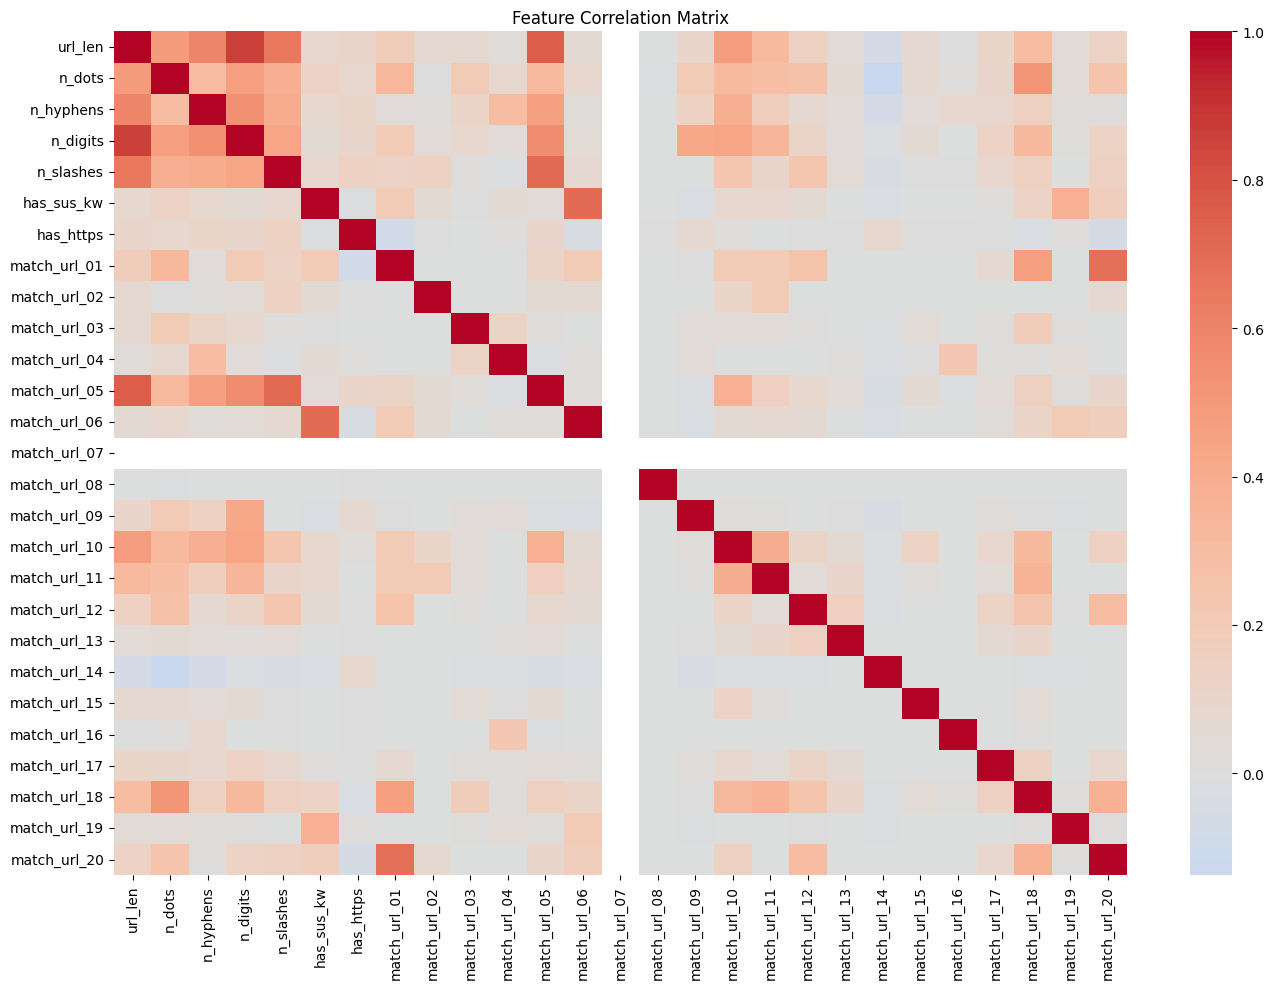


Top 10 Features Correlated with Phishing Label:
n_slashes       0.421785
n_dots          0.363312
has_https       0.337869
n_digits        0.320424
url_len         0.319914
n_hyphens       0.305051
match_url_05    0.273178
match_url_09    0.205005
match_url_14    0.169562
match_url_10    0.111800


In [23]:
print("="*60)
print("FEATURE CORRELATION ANALYSIS")
print("="*60)

# Analyze feature correlations to identify redundant features
# Highly correlated features (|r| > 0.7) may hurt model performance or cause overfitting
correlation_matrix = X_train.corr()

# Find pairs of features that are strongly correlated
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print("\nHighly Correlated Features (|r| > 0.7):")
    for pair in high_corr_pairs:
        print(f"  {pair['Feature 1']} <-> {pair['Feature 2']}: {pair['Correlation']:.3f}")
else:
    print("\nNo highly correlated feature pairs found.")

# Visualize the full correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Find which features are most predictive of phishing
feature_target_corr = X_train.apply(lambda col: col.corr(y_train)).sort_values(ascending=False)
print("\nTop 10 Features Correlated with Phishing Label:")
print(feature_target_corr.head(10).to_string())

CROSS-VALIDATION MODEL COMPARISON

5-Fold Cross-Validation Results:
----------------------------------------------------------------------

Random Forest:
  Accuracy: 0.8763 (+/- 0.0075)
  F1 Score: 0.8742 (+/- 0.0066)
  ROC-AUC:  0.9512 (+/- 0.0039)

Logistic Regression:
  Accuracy: 0.8337 (+/- 0.0069)
  F1 Score: 0.8262 (+/- 0.0084)
  ROC-AUC:  0.9194 (+/- 0.0047)

Gradient Boosting:
  Accuracy: 0.8765 (+/- 0.0095)
  F1 Score: 0.8702 (+/- 0.0098)
  ROC-AUC:  0.9535 (+/- 0.0023)

Naive Bayes:
  Accuracy: 0.6722 (+/- 0.0073)
  F1 Score: 0.5143 (+/- 0.0175)
  ROC-AUC:  0.8713 (+/- 0.0083)


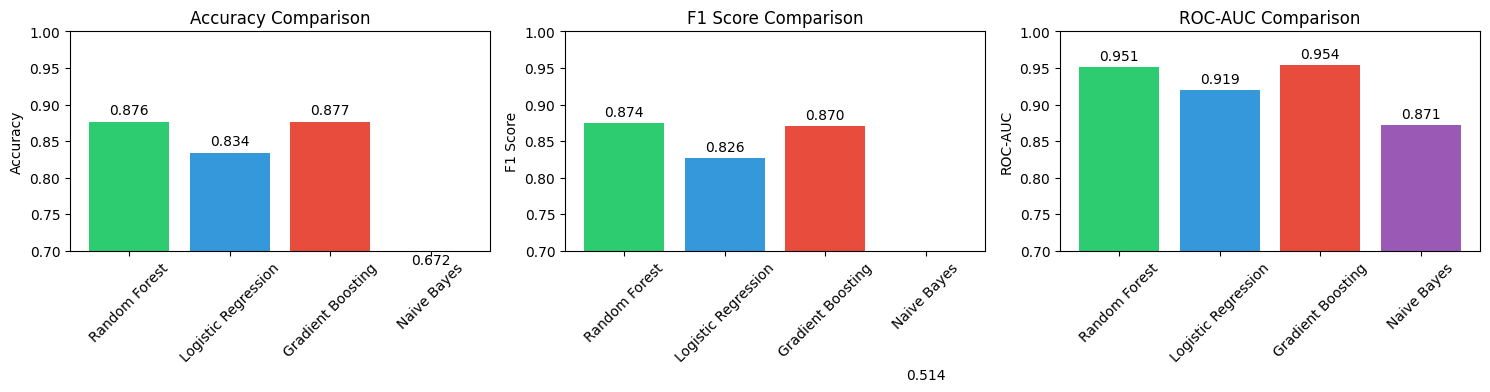


Best Model by F1 Score: Random Forest


In [24]:
print("="*60)
print("CROSS-VALIDATION MODEL COMPARISON")
print("="*60)

# Scale features for models that require it (Logistic Regression, Naive Bayes)
# Tree-based models (Random Forest, Gradient Boosting) don't need scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compare multiple classifiers to find the best approach
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB()
}

# 5-fold stratified CV gives robust performance estimates
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("\n5-Fold Cross-Validation Results:")
print("-" * 70)

for name, model in models.items():
    # Use scaled data for models that need it
    X_cv = X_train_scaled if name in ['Logistic Regression', 'Naive Bayes'] else X_train
    
    accuracy_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='f1')
    roc_auc_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc')
    
    results.append({
        'Model': name,
        'Accuracy': f"{accuracy_scores.mean():.4f} (+/- {accuracy_scores.std()*2:.4f})",
        'F1 Score': f"{f1_scores.mean():.4f} (+/- {f1_scores.std()*2:.4f})",
        'ROC-AUC': f"{roc_auc_scores.mean():.4f} (+/- {roc_auc_scores.std()*2:.4f})",
        'acc_mean': accuracy_scores.mean(),
        'f1_mean': f1_scores.mean(),
        'roc_mean': roc_auc_scores.mean()
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy_scores.mean():.4f} (+/- {accuracy_scores.std()*2:.4f})")
    print(f"  F1 Score: {f1_scores.mean():.4f} (+/- {f1_scores.std()*2:.4f})")
    print(f"  ROC-AUC:  {roc_auc_scores.mean():.4f} (+/- {roc_auc_scores.std()*2:.4f})")

# Visualize model comparison
results_df = pd.DataFrame(results)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('acc_mean', 'Accuracy'), ('f1_mean', 'F1 Score'), ('roc_mean', 'ROC-AUC')]
for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(results_df['Model'], results_df[col], color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
    ax.set_ylabel(title)
    ax.set_title(f'{title} Comparison')
    ax.set_ylim(0.7, 1.0)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, results_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

best_model_name = results_df.loc[results_df['f1_mean'].idxmax(), 'Model']
print(f"\nBest Model by F1 Score: {best_model_name}")

In [25]:
print("="*60)
print("HYPERPARAMETER TUNING (Random Forest)")
print("="*60)

# Define the hyperparameter search space
# These parameters control model complexity and regularization
param_distributions = {
    'n_estimators': [50, 100, 150, 200, 250, 300],      # Number of trees
    'max_depth': [10, 15, 20, 25, 30, None],            # Maximum tree depth
    'min_samples_split': [2, 5, 10, 15],                # Min samples to split a node
    'min_samples_leaf': [1, 2, 4, 6],                   # Min samples in leaf nodes
    'max_features': ['sqrt', 'log2', None],             # Features considered per split
    'bootstrap': [True, False]                           # Bootstrap sampling
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# RandomizedSearchCV is more efficient than GridSearchCV for large parameter spaces
# 50 iterations samples different parameter combinations randomly
print("Running RandomizedSearchCV (50 iterations)...")
random_search = RandomizedSearchCV(
    rf_base, param_distributions, n_iter=50, cv=5, 
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1 Score: {random_search.best_score_:.4f}")

best_rf_model = random_search.best_estimator_

HYPERPARAMETER TUNING (Random Forest)
Running RandomizedSearchCV (50 iterations)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters:
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: log2
  max_depth: 30
  bootstrap: True

Best CV F1 Score: 0.8772


ROC-AUC AND PRECISION-RECALL ANALYSIS

Test Set Performance:
  ROC-AUC Score: 0.9530
  Average Precision: 0.9595


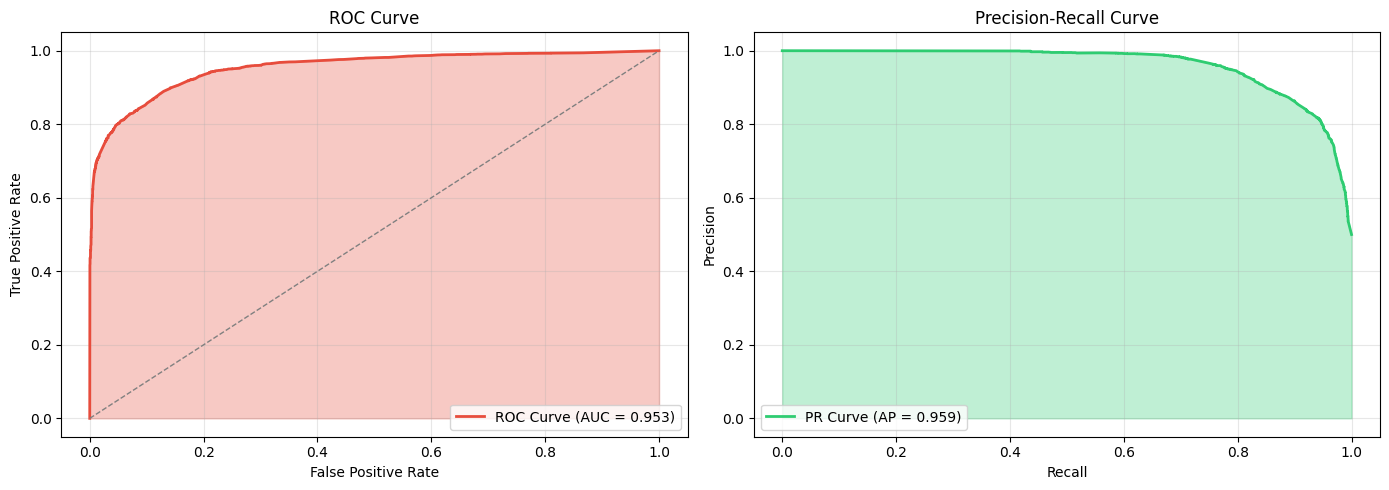


--- Threshold Analysis ---
 Threshold  Precision  Recall       F1  FP  FN
      0.30   0.814119 0.94275 0.873726 861 229
      0.35   0.834011 0.92325 0.876364 735 307
      0.40   0.840805 0.91900 0.878165 696 324
      0.45   0.877110 0.88325 0.880169 495 467
      0.50   0.889833 0.86425 0.876855 428 543
      0.55   0.922368 0.82575 0.871389 278 697
      0.60   0.939456 0.80300 0.865885 207 788
      0.65   0.949985 0.78350 0.858748 165 866
      0.70   0.959203 0.77000 0.854250 131 920
      0.75   0.962599 0.75925 0.848917 118 963

Recommended Threshold (max F1): 0.45


In [26]:
print("="*60)
print("ROC-AUC AND PRECISION-RECALL ANALYSIS")
print("="*60)

# Evaluate the tuned model on the held-out test set
y_pred = best_rf_model.predict(X_test)
y_proba = best_rf_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

print(f"\nTest Set Performance:")
print(f"  ROC-AUC Score: {roc_auc:.4f}")
print(f"  Average Precision: {avg_precision:.4f}")

# Plot ROC curve (shows tradeoff between true positive rate and false positive rate)
# and PR curve (more informative for imbalanced datasets)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall, precision, color='#2ecc71', lw=2, label=f'PR Curve (AP = {avg_precision:.3f})')
axes[1].fill_between(recall, precision, alpha=0.3, color='#2ecc71')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Threshold analysis: find optimal threshold for different use cases
# Lower threshold = catch more phishing (higher recall) but more false positives
# Higher threshold = fewer false positives but might miss some phishing
print("\n--- Threshold Analysis ---")
from sklearn.metrics import f1_score as f1_calc

thresholds_to_test = np.arange(0.3, 0.8, 0.05)
threshold_results = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_val = f1_calc(y_test, y_pred_thresh)
    threshold_results.append({'Threshold': thresh, 'Precision': precision_val, 'Recall': recall_val, 'F1': f1_val, 'FP': fp, 'FN': fn})

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

best_f1_idx = thresh_df['F1'].idxmax()
print(f"\nRecommended Threshold (max F1): {thresh_df.loc[best_f1_idx, 'Threshold']:.2f}")

FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
     feature  importance
     url_len    0.294995
    n_digits    0.219073
   n_slashes    0.135047
      n_dots    0.123558
   has_https    0.088231
   n_hyphens    0.065961
match_url_14    0.029350
match_url_09    0.012135
match_url_05    0.011101
match_url_06    0.005192
  has_sus_kw    0.004926
match_url_04    0.002838
match_url_19    0.002381
match_url_12    0.001672
match_url_10    0.001272


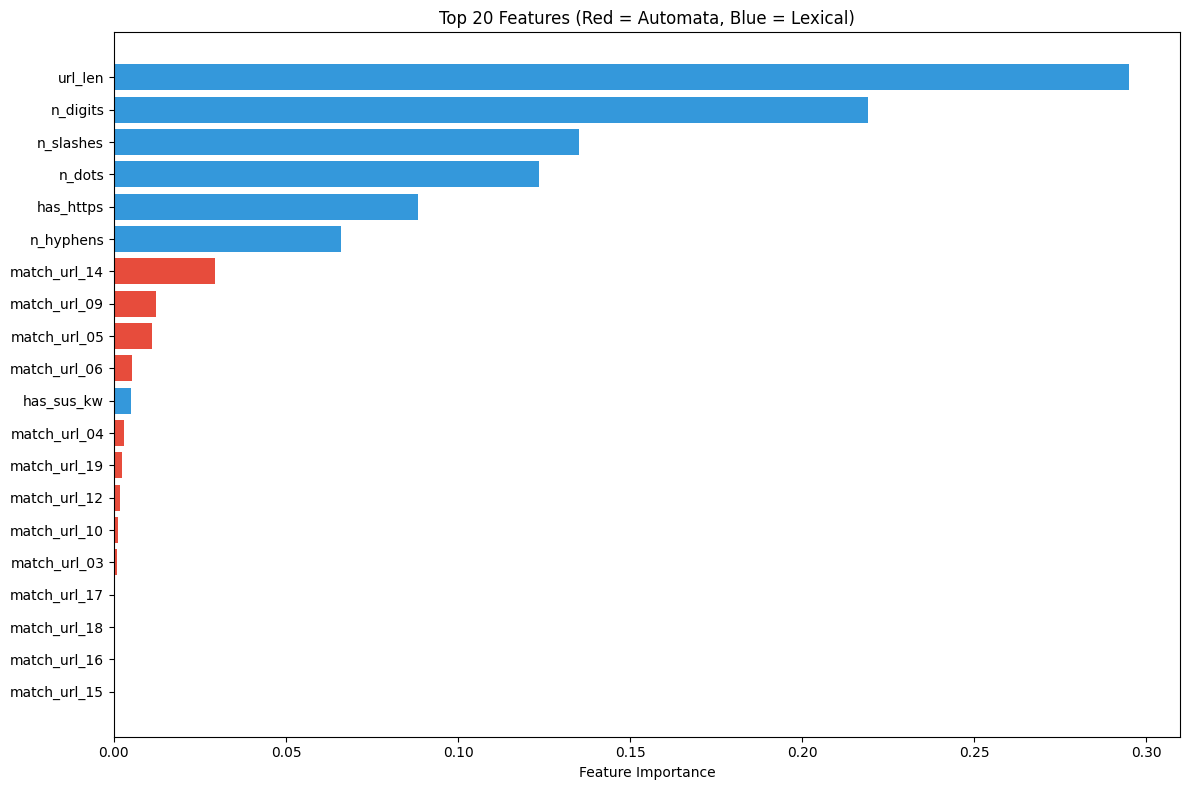


Feature Type Contribution:
  Lexical Features:  93.18%
  Automata Features: 6.82%


In [27]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Extract feature importances from the trained Random Forest
# This shows which features contribute most to predictions
importances = pd.DataFrame({
    'feature': hybrid_features,
    'importance': best_rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importances.head(15).to_string(index=False))

# Visualize top 20 features, color-coded by type
plt.figure(figsize=(12, 8))
top_20 = importances.head(20)
colors = ['#e74c3c' if f.startswith('match_') else '#3498db' for f in top_20['feature']]
plt.barh(range(len(top_20)), top_20['importance'], color=colors)
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Features (Red = Automata, Blue = Lexical)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Compare total contribution from each feature type
# This helps evaluate if the automata rules add value beyond lexical features
automata_importance = importances[importances['feature'].str.startswith('match_')]['importance'].sum()
lexical_importance = importances[~importances['feature'].str.startswith('match_')]['importance'].sum()

print(f"\nFeature Type Contribution:")
print(f"  Lexical Features:  {lexical_importance:.2%}")
print(f"  Automata Features: {automata_importance:.2%}")

FINAL MODEL EVALUATION & EXPORT

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       0.87      0.89      0.88      4000
    Phishing       0.89      0.86      0.88      4000

    accuracy                           0.88      8000
   macro avg       0.88      0.88      0.88      8000
weighted avg       0.88      0.88      0.88      8000



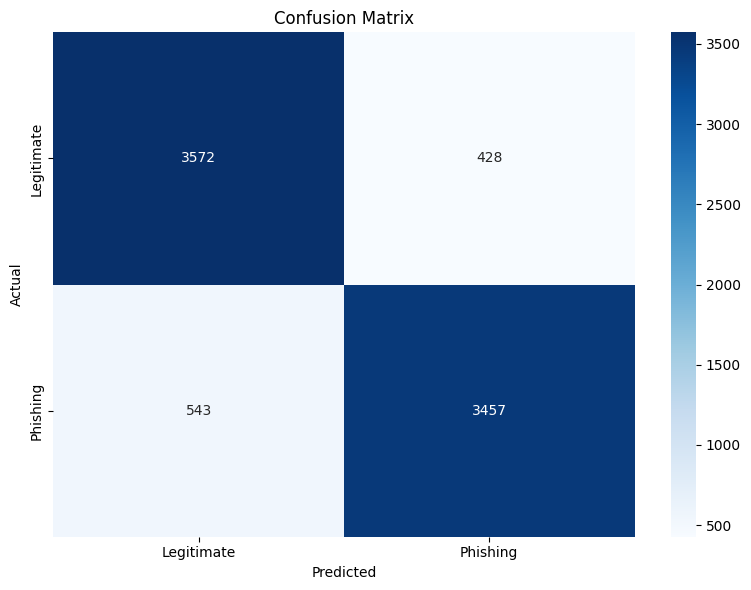


Final Metrics: Accuracy=0.8786, F1=0.8769, ROC-AUC=0.9530

--- Inference Time ---
Single prediction: 16.820 ms
Batch of 10: 17.35 ms (1.735 ms/sample)
Batch of 100: 17.12 ms (0.171 ms/sample)
Batch of 1000: 17.08 ms (0.017 ms/sample)

--- Saving Model ---
Models saved to data/processed/

BACKEND INTEGRATION INFO

Model: Random Forest (27 features)
Performance: Accuracy=87.86%, F1=87.69%, ROC-AUC=0.9530
Inference: ~16.82 ms per prediction

Usage:
  model_pkg = joblib.load('phishing_model.joblib')
  model = model_pkg['model']
  prediction = model.predict(feature_vector)
  probability = model.predict_proba(feature_vector)[:, 1]



In [28]:
import joblib
import sklearn
import time
from datetime import datetime

print("="*60)
print("FINAL MODEL EVALUATION & EXPORT")
print("="*60)

# Detailed classification report with precision, recall, F1 per class
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

# Confusion matrix shows true/false positives and negatives
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

final_accuracy = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)
final_roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nFinal Metrics: Accuracy={final_accuracy:.4f}, F1={final_f1:.4f}, ROC-AUC={final_roc_auc:.4f}")

# Measure inference time - important for backend API performance planning
print("\n--- Inference Time ---")
_ = best_rf_model.predict(X_test[:10])  # Warm-up run
n_iterations = 1000
single_sample = X_test.iloc[[0]]

start_time = time.perf_counter()
for _ in range(n_iterations):
    _ = best_rf_model.predict(single_sample)
avg_inference_ms = (time.perf_counter() - start_time) / n_iterations * 1000
print(f"Single prediction: {avg_inference_ms:.3f} ms")

for batch_size in [10, 100, 1000]:
    batch = X_test.iloc[:batch_size]
    start_time = time.perf_counter()
    _ = best_rf_model.predict(batch)
    batch_time_ms = (time.perf_counter() - start_time) * 1000
    print(f"Batch of {batch_size}: {batch_time_ms:.2f} ms ({batch_time_ms/batch_size:.3f} ms/sample)")

# Save model with all metadata needed for reproducibility and deployment
print("\n--- Saving Model ---")
model_package = {
    'model': best_rf_model,
    'feature_names': hybrid_features,
    'best_params': random_search.best_params_,
    'metrics': {'accuracy': final_accuracy, 'f1_score': final_f1, 'roc_auc': final_roc_auc},
    'threshold': 0.5,
    'training_info': {
        'date': datetime.now().isoformat(),
        'sklearn_version': sklearn.__version__,
        'n_train': len(X_train),
        'n_test': len(X_test)
    }
}

joblib.dump(model_package, '../data/processed/phishing_model.joblib')
joblib.dump(best_rf_model, '../data/processed/phishing_model_simple.joblib')
print("Models saved to data/processed/")

print("\n" + "="*60)
print("BACKEND INTEGRATION INFO")
print("="*60)
print(f"""
Model: Random Forest ({len(hybrid_features)} features)
Performance: Accuracy={final_accuracy:.2%}, F1={final_f1:.2%}, ROC-AUC={final_roc_auc:.4f}
Inference: ~{avg_inference_ms:.2f} ms per prediction

Usage:
  model_pkg = joblib.load('phishing_model.joblib')
  model = model_pkg['model']
  prediction = model.predict(feature_vector)
  probability = model.predict_proba(feature_vector)[:, 1]
""")